# Olist E-Commerce Analysis


## Notebook 01: Data Cleaning and Preparation


**Project:** End-to-end analysis of the Brazilian Olist e-commerce dataset, covering
sales performance, delivery efficiency, payment behavior, and customer satisfaction.
This is the Python component of a larger project that also includes Excel data
mapping and SQL business analysis.

### Objective of this Notebook
Prepare clean, analysis-ready datasets from the raw Olist CSV files so that
Notebook 02 (EDA & Business Analysis) and Notebook 03 (Insights & Visualization)
can work with reliable, well-structured data.

### What We Will Perform in This Notebook
1. **Import libraries** — pandas, numpy, matplotlib, seaborn
2. **Load all 9 raw datasets** — customers, orders, order items, payments,
   reviews, products, sellers, geolocation, category translation
3. **Initial inspection** — shape, dtypes, `.info()`, `.head()` for each dataset
4. **Missing value analysis** — identify and quantify nulls across all datasets
5. **Handle missing values** — drop, impute, or flag depending on the column
6. **Fix data types** — convert date/timestamp columns to `datetime`, fix
   incorrect numeric/categorical types
7. **Handle duplicates** — check and remove duplicate rows where applicable
8. **Outlier detection** — check price and freight value for outliers using
   boxplots and IQR; understand the spread without removing genuine data
9. **Merge/translate categories** — map English product category names using
   the translation table
10. **Merge core tables** — build a master orders-level dataframe joining
    orders, customers, order items, payments, and reviews
11. **Export clean datasets** — save cleaned CSV files to `data/clean/`
    for use in the next notebooks


### Step 1: Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load all 9 raw datasets

In [2]:
customers = pd.read_csv("olist_customers.csv")
orders = pd.read_csv("olist_orders.csv")
order_items = pd.read_csv("olist_order_items.csv")
order_payments = pd.read_csv("olist_order_payments.csv")
order_reviews = pd.read_csv("olist_order_reviews.csv")
products = pd.read_csv("olist_products.csv")
sellers = pd.read_csv("olist_sellers.csv")
geolocation = pd.read_csv("olist_geolocation.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
order_payments (103886, 5)
order_reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)
geolocation (1000163, 5)
category_translation (71, 2)


### Step 3: Initial inspection — shape, dtypes, .info(), .head()

In [3]:
for name, df in datasets.items():
    print("=" * 40)
    print(name)
    print("=" * 40)
    print(df.info())
    print()

customers
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

orders
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approve

### Step 4: Missing value analysis

In [4]:
for name, df in datasets.items():
    print("=" * 40)
    print(name)
    print("=" * 40)
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(missing)
    print()

customers
Series([], dtype: int64)

orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

order_items
Series([], dtype: int64)

order_payments
Series([], dtype: int64)

order_reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

sellers
Series([], dtype: int64)

geolocation
Series([], dtype: int64)

category_translation
Series([], dtype: int64)



### Step 5: Handle missing values

In [5]:
# 1. Order reviews - comment title/message are optional, so blank means no comment
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].fillna('No Title')
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].fillna('No Comment')

# 2. Orders - delivery dates missing usually means order wasn't delivered/approved yet
# We keep these as NaT (missing date) since filling them with fake dates would be wrong
# We'll just check how many rows are affected
print("Missing approved_at:", orders['order_approved_at'].isnull().sum())
print("Missing delivered_carrier_date:", orders['order_delivered_carrier_date'].isnull().sum())
print("Missing delivered_customer_date:", orders['order_delivered_customer_date'].isnull().sum())

# 3. Products - fill missing category with 'unknown', missing numeric details with 0
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products['product_weight_g'] = products['product_weight_g'].fillna(0)
products['product_length_cm'] = products['product_length_cm'].fillna(0)
products['product_height_cm'] = products['product_height_cm'].fillna(0)
products['product_width_cm'] = products['product_width_cm'].fillna(0)

print("\nMissing values handled.")

Missing approved_at: 160
Missing delivered_carrier_date: 1783
Missing delivered_customer_date: 2965

Missing values handled.


### Step 6: Fix data types

In [6]:
# Convert order date columns from text to actual datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Convert review dates too
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'])

# Check it worked
print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


### Step 7: Handle duplicates

In [7]:
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    print(name, "duplicate rows:", dup_count)

customers duplicate rows: 0
orders duplicate rows: 0
order_items duplicate rows: 0
order_payments duplicate rows: 0
order_reviews duplicate rows: 0
products duplicate rows: 0
sellers duplicate rows: 0
geolocation duplicate rows: 261831
category_translation duplicate rows: 0


In [8]:
geolocation = geolocation.drop_duplicates()

print("geolocation shape after removing duplicates:", geolocation.shape)

geolocation shape after removing duplicates: (738332, 5)


In [9]:
datasets['geolocation'] = geolocation

### Step 8: Outlier Detection

Before merging and exporting the data, we check for outliers in key numeric
columns (price, freight value, payment_value). We identify them using the boxplot method,
but we choose not to remove them — in e-commerce data, unusually high-priced
orders or freight charges are often genuine business events, not errors.
This step is to understand the data's spread, not to clean it.

In [16]:
# Check summary statistics
print(order_items[['price', 'freight_value']].describe())
print(order_payments[['payment_value']].describe())


               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000
       payment_value
count  103886.000000
mean      154.100380
std       217.494064
min         0.000000
25%        56.790000
50%       100.000000
75%       171.837500
max     13664.080000


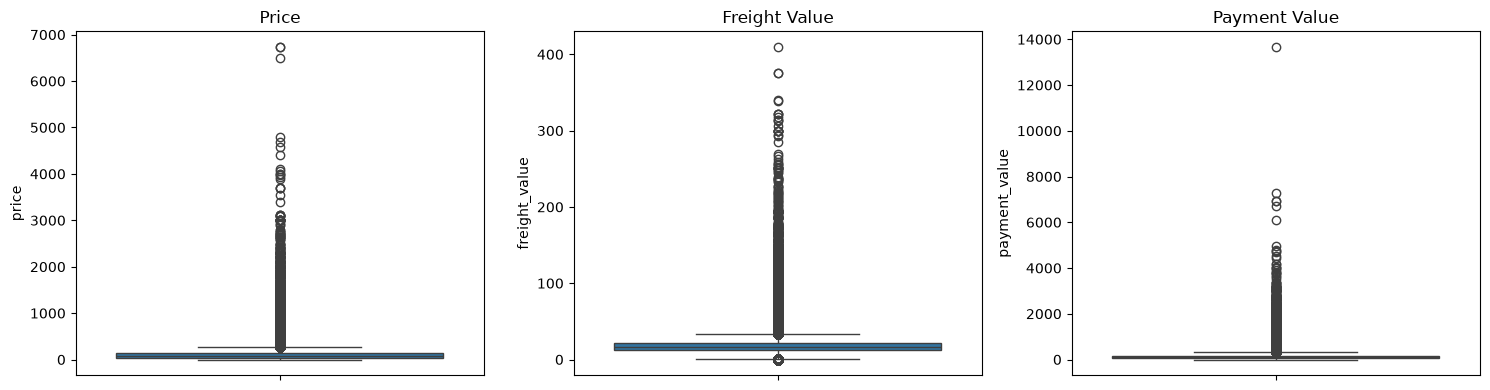

In [17]:
# Visualize with boxplots
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=order_items['price'])
plt.title('Price')

plt.subplot(1, 3, 2)
sns.boxplot(y=order_items['freight_value'])
plt.title('Freight Value')

plt.subplot(1, 3, 3)
sns.boxplot(y=order_payments['payment_value'])
plt.title('Payment Value')

plt.tight_layout()
plt.show()


In [19]:
# Count how many rows fall beyond the IQR-based upper bound (for reference only)
Q1 = order_items['price'].quantile(0.25)
Q3 = order_items['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outlier_count = (order_items['price'] > upper_bound).sum()
print(f"Number of price outliers (IQR method): {outlier_count}")

Q1_freight = order_items['freight_value'].quantile(0.25)
Q3_freight = order_items['freight_value'].quantile(0.75)
IQR_freight = Q3_freight - Q1_freight
upper_bound_freight = Q3_freight + 1.5 * IQR_freight
outlier_count_freight = (order_items['freight_value'] > upper_bound_freight).sum()
print(f"Number of freight_value outliers (IQR method): {outlier_count_freight}")

Q1_pay = order_payments['payment_value'].quantile(0.25)
Q3_pay = order_payments['payment_value'].quantile(0.75)
IQR_pay = Q3_pay - Q1_pay
upper_bound_pay = Q3_pay + 1.5 * IQR_pay
outlier_count_pay = (order_payments['payment_value'] > upper_bound_pay).sum()
print(f"Number of payment_value outliers (IQR method): {outlier_count_pay}")

Number of price outliers (IQR method): 8427
Number of freight_value outliers (IQR method): 11613
Number of payment_value outliers (IQR method): 7981


### Step 9: Merge/Translate Product Categories

**Why:** The original `product_category_name` column is in Portuguese. Merging in
the English translation from `category_translation` adds a new column
`product_category_name_english`, which is easier to use in charts and analysis.

In [10]:
products = products.merge(category_translation, on='product_category_name', how='left')

products[['product_category_name', 'product_category_name_english']].head()

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares


### Step 10: Merge Core Tables into a Master Dataframe

**Why:** Each raw table only tells part of the story. Merging orders, customers,
order items, products, sellers, payments, and reviews on shared keys
(`customer_id`, `order_id`, `product_id`, `seller_id`) gives one combined table
with everything — customer location, product category, seller, payment, and
review score. This `master_df` will be used for most of the analysis in Notebook 02.

In [11]:
# Start with orders, then join customer info
master_df = orders.merge(customers, on='customer_id', how='left')

# Add order items (product, price, freight per item)
master_df = master_df.merge(order_items, on='order_id', how='left')

# Add product details (including English category name)
master_df = master_df.merge(products, on='product_id', how='left')

# Add seller info
master_df = master_df.merge(sellers, on='seller_id', how='left')

# Add payment info
master_df = master_df.merge(order_payments, on='order_id', how='left')

# Add review info
master_df = master_df.merge(order_reviews, on='order_id', how='left')

print("Master dataframe shape:", master_df.shape)
master_df.head()

Master dataframe shape: (119143, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18,2018-08-22 19:07:58


### Step 11: Export Clean Datasets

**Why:** Saving the cleaned, merged data to disk lets Notebook 02 (EDA) load
these files directly instead of repeating all the cleaning steps.

In [12]:
master_df.to_csv("master_df_clean.csv", index=False)
products.to_csv("products_clean.csv", index=False)
geolocation.to_csv("geolocation_clean.csv", index=False)

### Result

Cleaned all missing values, fixed data types (dates now proper `datetime`),
and removed 261,831 duplicate geolocation rows. Checked price, freight, and
payment values for outliers using the IQR method — flagged but retained,
since they represent genuine high-value orders rather than data errors.
Product categories are now readable in English, and all tables are merged
into a single `master_df` covering orders, customers, products, sellers,
payments, and reviews. Clean data exported to disk, ready for EDA in Notebook 02.